# Low Pass Filter Characterization (Frequency Sweep)

This notebook performs a frequency sweep to characteristize a component or loopback connection, such as a low-pass filter. It works by running the same data acquisition program (`LoopbackProgram`) repeatedly, each time with an incremented pulse frequency and matched readout frequency.

First, we import the necessary libraries. We import `qick` to interface with the RFSoC, and `numpy`/`pylab` for numerical operations and plotting.

In [2]:
# Import QICK drivers and auxiliary libraries
from qick import *
import numpy as np
import matplotlib.pyplot as plt
%pylab inline

# Initialize the QICK System-on-Chip (SoC)
# This establishes the connection to the FPGA and loads the hardware configuration.
soc = QickSoc()
soccfg = soc
print(soccfg)

# Define the generator (DAC) and readout (ADC) channels based on our hardware setup.
GEN_CH = 3
RO_CH = 1

Populating the interactive namespace from numpy and matplotlib


OSError: Root permissions required.

## 1. Defining the QICK Program

The core of our measurement is the `LoopbackProgram` class, which inherits from `AveragerProgram`. `AveragerProgram` is a convenient base class provided by QICK that handles the repetitive playing of a sequence and averaging the readouts in hardware, which is much faster than doing it in software.

### `initialize(self)`
This method is run once at the start of the program to configure the hardware registers before any time-critical execution begins. We do the following:
1. **`declare_gen` / `declare_readout`**: These allocate the DAC and ADC channels we intend to use. We pass the length and frequency. We also specify `gen_ch` when declaring the readout so that the ADC downconversion frequency is strictly phase-matched to the DAC upconversion frequency.
2. **`freq2reg` etc.**: We convert real-world values (MHz, degrees) into the integer representations understandable by the FPGA registers.
3. **`set_pulse_registers`**: We pre-load the generator registers with the pulse parameters (frequency, phase, gain, style, length) so that they are ready to fire instantly during the `body` execution.
4. **`synci`**: At the end of initialization, we wait a fixed number of clock cycles to give the control processor time to finish loading these parameters before the sequence begins.

### `body(self)`
This method defines the actual sequence of timed events executed by the FPGA's tProcessor. The sequence will be repeated `reps` times.
1. **`measure()`**: This is a macro that simultaneously fires a pulse on `pulse_ch` and triggers the `adcs`. 
   - `wait=True` pauses the sequential execution until the readout finishes.
   - `syncdelay` adds a delay (relaxation time) at the end of the shot to ensure the system returns to steady state before the next repetition begins.

In [ ]:
class LoopbackProgram(AveragerProgram):
    def initialize(self):
        cfg = self.cfg
        res_ch = cfg["res_ch"]

        # 1. Declare the generator and readout channels
        # nqz=1 implies Nyquist zone 1 (for frequencies from 0 to half the sampling rate)
        self.declare_gen(ch=res_ch, nqz=1)
        
        # Declare readout channel(s)
        # gen_ch is provided to ensure the ADC strictly frequency-matches the DAC
        for ch in cfg["ro_chs"]:
            self.declare_readout(ch=ch, length=self.cfg["readout_length"],
                                 freq=self.cfg["pulse_freq"], gen_ch=res_ch)

        # 2. Convert readable physical units into register values
        freq = self.freq2reg(cfg["pulse_freq"], gen_ch=res_ch, ro_ch=cfg["ro_chs"][0])
        phase = self.deg2reg(cfg["res_phase"], gen_ch=res_ch)
        gain = cfg["pulse_gain"]

        # 3. Load pulse parameters into the registers associated with the DAC channel
        style = self.cfg["pulse_style"]
        if style == "const":
            self.set_pulse_registers(ch=res_ch, style=style, freq=freq, phase=phase, gain=gain, length=cfg["length"])
        
        # 4. Synchronize before body starts
        self.synci(200)  # give processor 200 clock ticks to configure pulses
    
    def body(self):
        # Trigger the pulse and measurement simultaneously, wait for readout to finish, 
        # and then wait an additional 'relax_delay' before the next repetition.
        self.measure(pulse_ch=self.cfg["res_ch"], 
                     adcs=self.ro_chs,
                     pins=[0], # Trigger a PMOD pin for oscilloscope sync if needed
                     adc_trig_offset=self.cfg["adc_trig_offset"],
                     wait=True,
                     syncdelay=self.us2cycles(self.cfg["relax_delay"]))


## 2. Configuring and Executing the Frequency Sweep

We will set up a loop that iterates over a range of frequencies. For each frequency:
1. We update the `pulse_freq` parameter in our configuration dictionary.
2. We instantiate our `LoopbackProgram` with the updated config.
3. We call `acquire(soc)`, which compiles the program, loads it onto the FPGA, triggers the sequence, and returns the accumulated I and Q answers as an array.
4. We calculate the magnitude from the I and Q components: `Magnitude = sqrt(I^2 + Q^2)` or equivalently `abs(I + j*Q)`.

`acquire()` is used here instead of `acquire_decimated()`. `acquire()` returns a single averaged I/Q data point per shot (by aggregating the data buffered internally on the hardware), which is faster and exactly what we want for characterizing the amplitude at a given frequency point.

In [ ]:
# Define the base configuration dictionary
config = {
    "res_ch": GEN_CH, # DAC channel
    "ro_chs": [RO_CH], # ADC channel(s)
    "reps": 100,      # Number of hardware averages per frequency point
    "relax_delay": 1.0, # Time to wait between repetitions (us)
    "res_phase": 0,   # Constant phase
    "pulse_style": "const", # Rectangular pulse without envelope
    
    "length": 50,     # Pulse duration in clock ticks
    "readout_length": 200, # Readout duration in clock ticks
    "pulse_gain": 10000, # Signal amplitude (DAC units, max ~30000)
    "adc_trig_offset": 100, # Align the ADC capture window with the pulse arrival
    "soft_avgs": 1    # Software averages (we're using hardware 'reps' instead)
}

# Define sweep parameters
start_freq = 10 # MHz
stop_freq = 1000 # MHz
num_points = 100
frequencies = np.linspace(start_freq, stop_freq, num_points)

# Arrays to store our results
i_data = []
q_data = []
mag_data = []

print("Starting Frequency Sweep...")
for freq in frequencies:
    config["pulse_freq"] = freq
    
    # Create and run the program for the current frequency
    prog = LoopbackProgram(soccfg, config)
    avgi, avgq = prog.acquire(soc, progress=False)
    
    # avgi and avgq are arrays containing results for all declared ro_chs.
    # Since we only declared one (ro_chs[0]), we take the 0th element.
    # Furthermore, avgi[0] contains an array of results if there were multiple soft_avgs / shots.
    # The default acquire returns [channels][shots/soft_avgs]. We extract the singular float.
    i_val = avgi[0][0]
    q_val = avgq[0][0]
    
    # Calculate magnitude
    mag_val = np.abs(i_val + 1j * q_val)
    
    i_data.append(i_val)
    q_data.append(q_val)
    mag_data.append(mag_val)
    
    # Calculate phase shift
    phase_data = np.arctan2(q_data, i_data)

print("Sweep Complete!")

Starting Frequency Sweep...
Sweep Complete!


## 3. Visualizing Results

Finally, we plot the accumulated data using `matplotlib`.
We create a figure with subplots to visualize the magnitude (the primary indicator of a low-pass filter's dropoff) and the individual I and Q quadrature components.

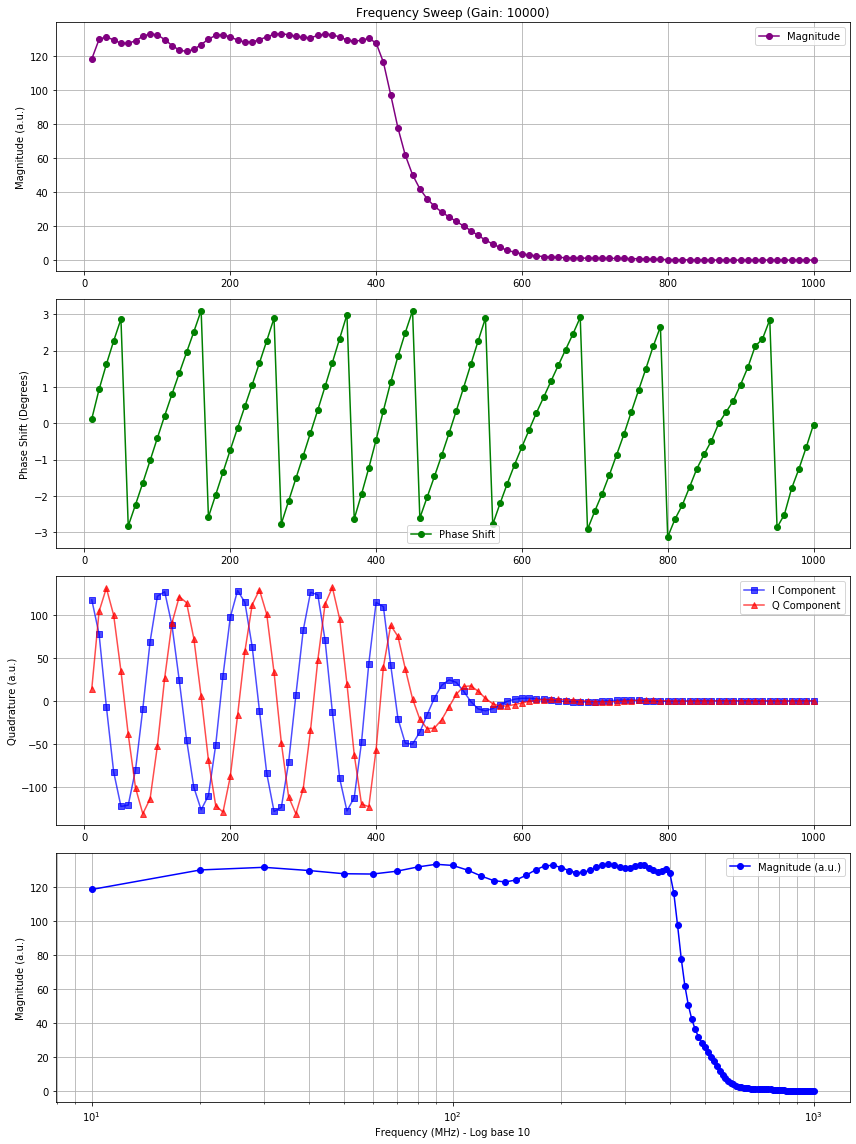

In [ ]:
plt.figure(figsize=(12, 16))

# Subplot 1: Magnitude (Linear)
plt.subplot(4, 1, 1)
plt.plot(frequencies, mag_data, '-o', color='purple', label='Magnitude')
plt.title(f'Frequency Sweep (Gain: {config["pulse_gain"]})')
plt.ylabel('Magnitude (a.u.)')
plt.grid(True)
plt.legend()

# Subplot 2: Phase Shift
plt.subplot(4, 1, 2)
plt.plot(frequencies, phase_data, '-o', color='green', label='Phase Shift')
plt.ylabel('Phase Shift (Degrees)')
plt.grid(True)
plt.legend()

# Subplot 3: I and Q components
plt.subplot(4, 1, 3)
plt.plot(frequencies, i_data, '-s', color='blue', label='I Component', alpha=0.7)
plt.plot(frequencies, q_data, '-^', color='red', label='Q Component', alpha=0.7)
plt.ylabel('Quadrature (a.u.)')
plt.grid(True)
plt.legend()

# Subplot 4: Magnitude (Log-X Scale)
plt.subplot(4, 1, 4)
plt.plot(frequencies, mag_data, '-o', color='blue', label='Magnitude (a.u.)')
plt.xscale('log') # This turns the x-axis into a log scale automatically
plt.xlabel('Frequency (MHz) - Log base 10')
plt.ylabel('Magnitude (a.u.)')
plt.grid(True, which="both", ls="-") # 'both' shows major and minor grid lines
plt.legend()

plt.tight_layout()
plt.show()
